**K Choice and Playstyles Clustering**

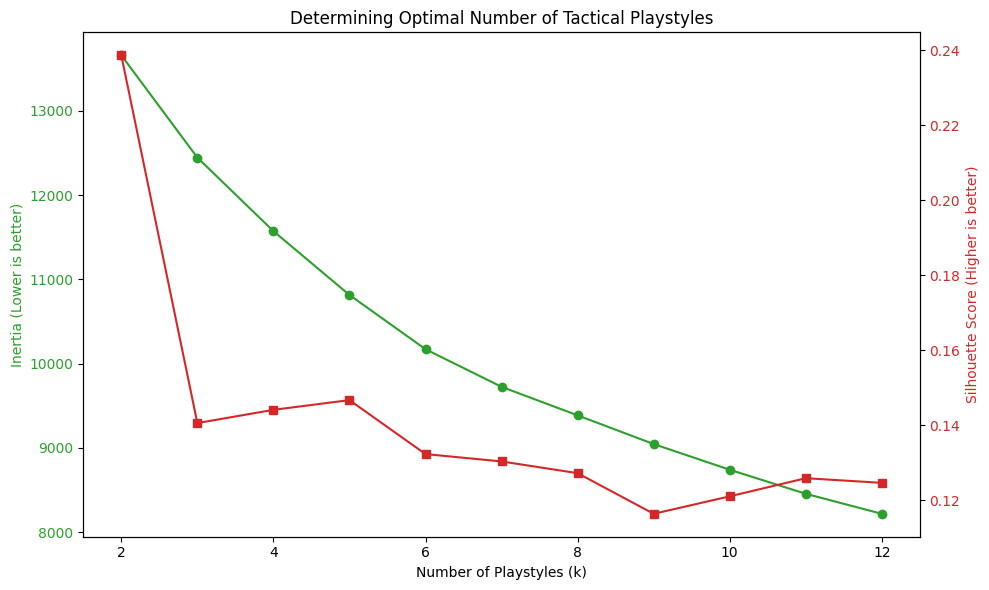

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
def evaluate_optimal_clusters(df, max_k=12):
    """
    Calculates the Elbow Curve (Inertia) and Silhouette Scores to 
    mathematically determine the optimal number of tactical playstyles.
    """
    
    style_features = [
        'passes_rolling', 'shots_rolling', 'xg_rolling', 'pressures_rolling', 
        'ball_recoveries_rolling', 'interceptions_rolling', 'possession_events_rolling', 
        'pressing_efficiency_rolling', 'shot_quality_rolling', 'directness_index_rolling', 
        'chaos_index_rolling', 'xg_volatility', 'pressures_volatility'
    ]
    
    df_clustering = df.dropna(subset=style_features).copy()
    
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df_clustering[style_features])
    
    inertias = []
    silhouette_scores = []
    k_values = range(2, max_k + 1)
    
    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(scaled_data)
        
        inertias.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(scaled_data, labels))
        
    # Plotting the results
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Plot Elbow Curve (Inertia)
    color = 'tab:green'
    ax1.set_xlabel('Number of Playstyles (k)')
    ax1.set_ylabel('Inertia (Lower is better)', color=color)
    ax1.plot(k_values, inertias, marker='o', color=color)
    ax1.tick_params(axis='y', labelcolor=color)

    # Plot Silhouette Score
    ax2 = ax1.twinx()  
    color = 'tab:red'
    ax2.set_ylabel('Silhouette Score (Higher is better)', color=color)
    ax2.plot(k_values, silhouette_scores, marker='s', color=color)
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title('Determining Optimal Number of Tactical Playstyles')
    fig.tight_layout()  
    plt.show()

final_prematch_df = pd.read_csv('Final_Data.csv')
evaluate_optimal_clusters(final_prematch_df)

**Playstyles**

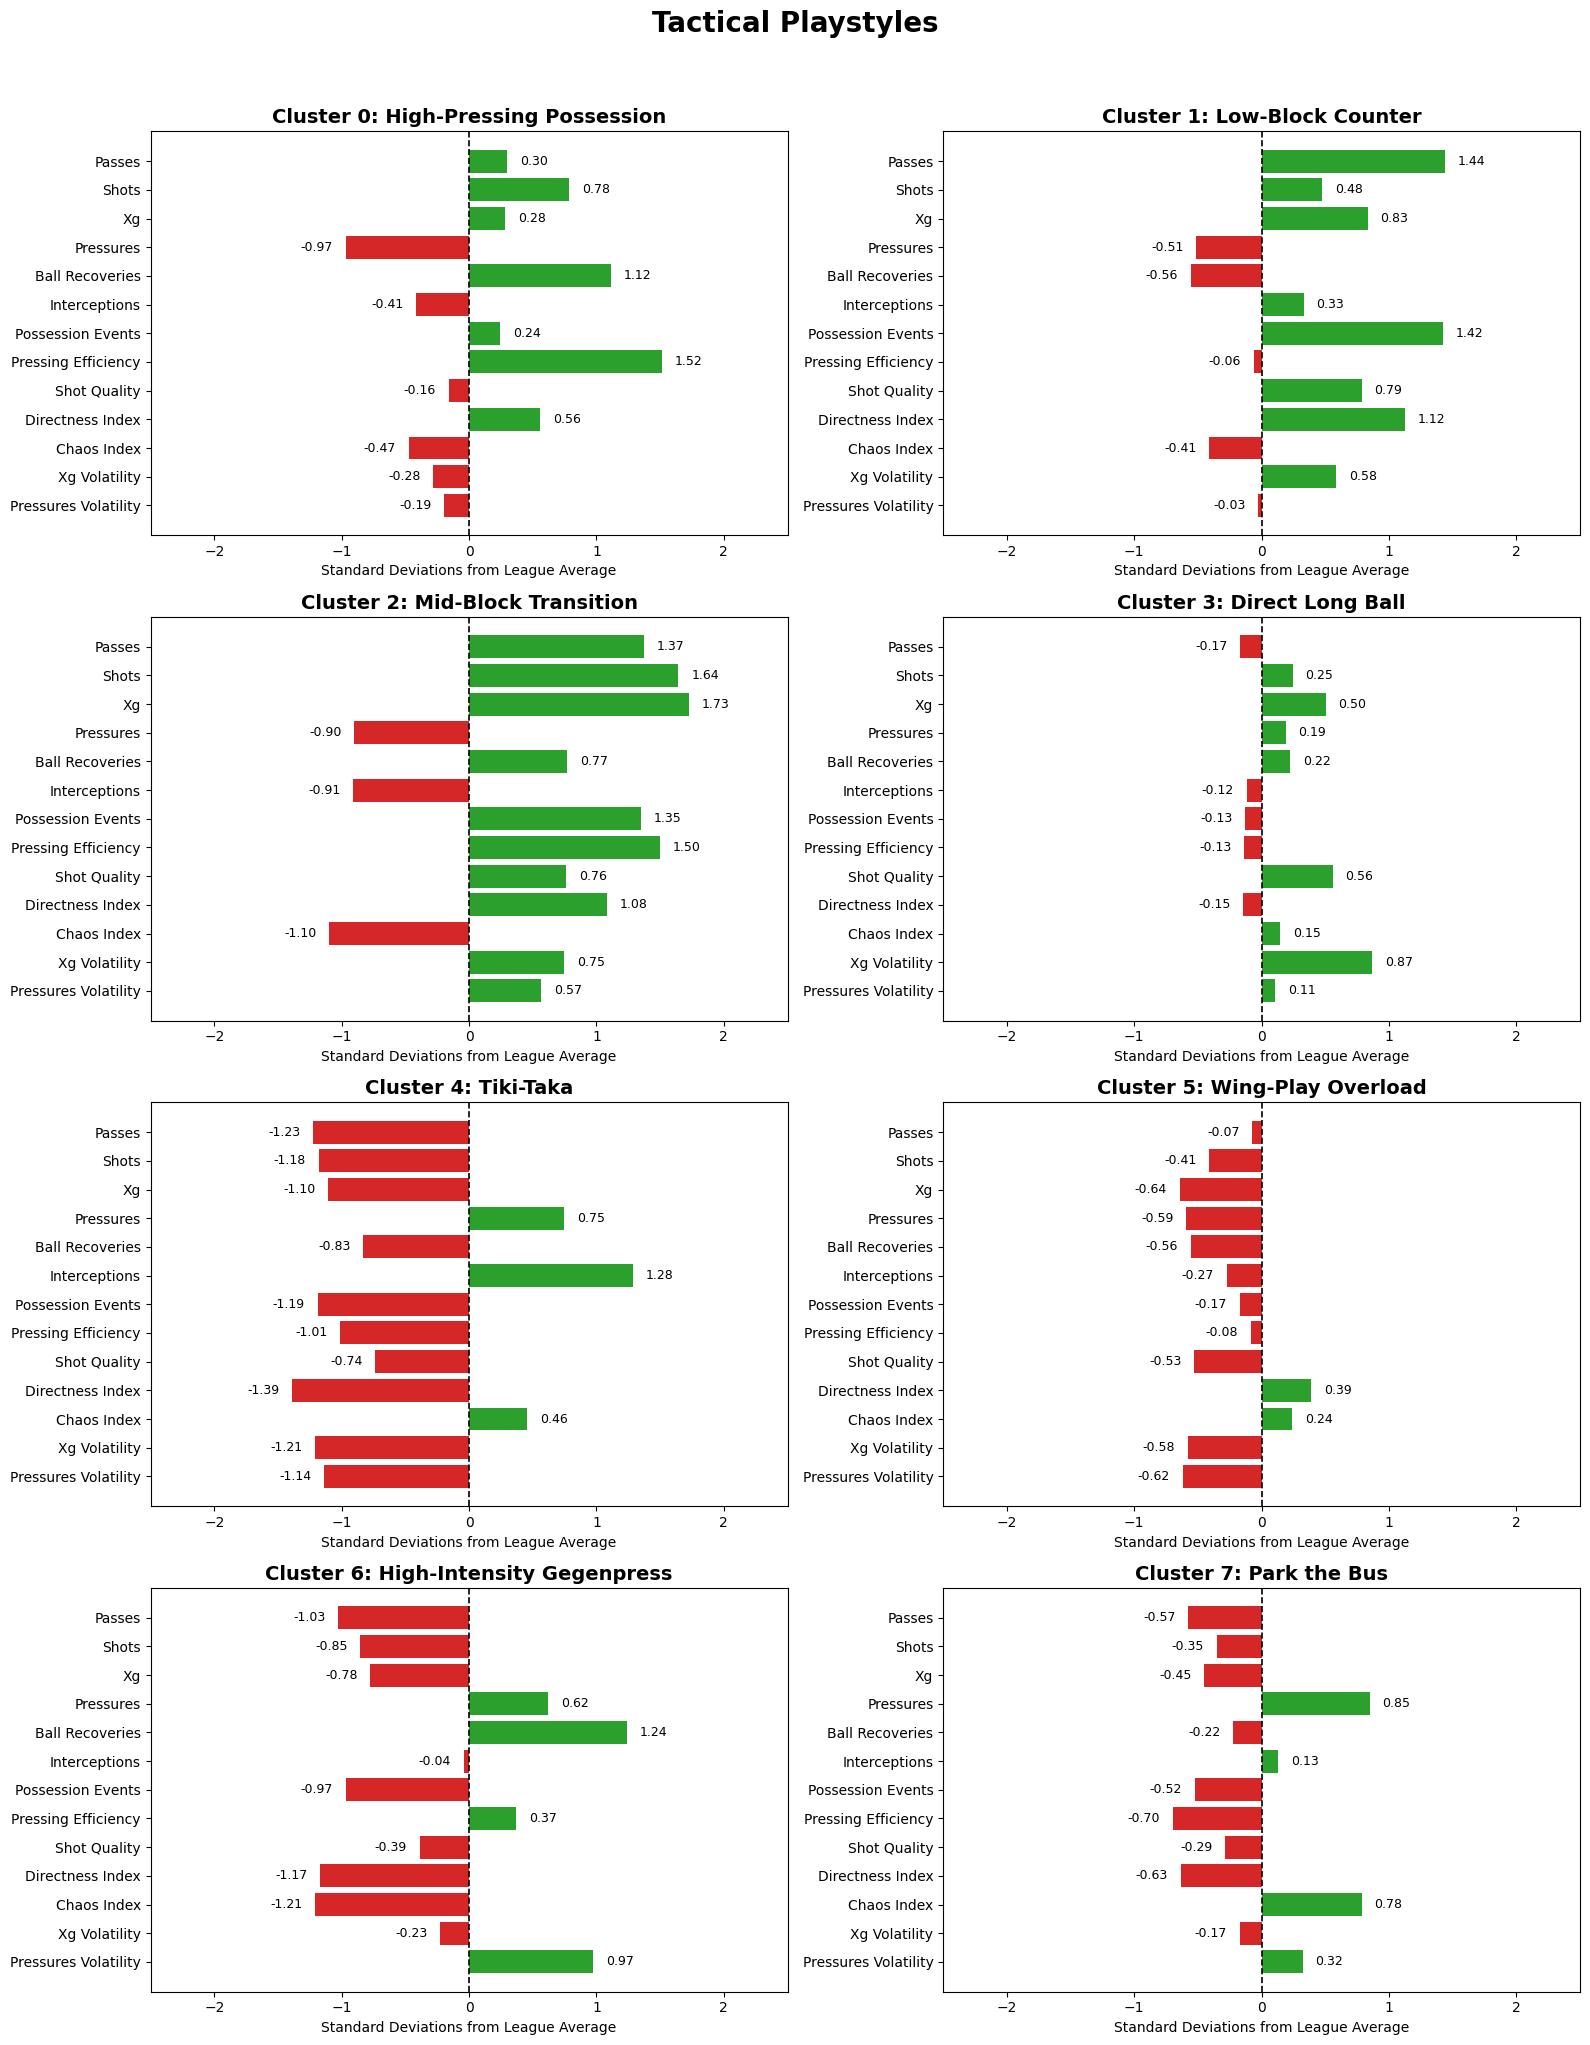

In [4]:
def visualize_playstyles(df):
    # The exact features used for clustering
    style_features = [
        'passes_rolling', 'shots_rolling', 'xg_rolling', 'pressures_rolling', 
        'ball_recoveries_rolling', 'interceptions_rolling', 'possession_events_rolling', 
        'pressing_efficiency_rolling', 'shot_quality_rolling', 'directness_index_rolling', 
        'chaos_index_rolling', 'xg_volatility', 'pressures_volatility'
    ]
    
    # Clean data and scale
    df_clustering = df.dropna(subset=style_features).copy()
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df_clustering[style_features])
    
    # Fit K-Means with exactly 8 clusters
    kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    
    # Extract the cluster centers (these are in z-scores / standard deviations)
    centers = pd.DataFrame(kmeans.cluster_centers_, columns=style_features)
    
    # The names from our Streamlit Engine
    tactic_names = {
        0: "High-Pressing Possession", 1: "Low-Block Counter",
        2: "Mid-Block Transition", 3: "Direct Long Ball",
        4: "Tiki-Taka", 5: "Wing-Play Overload",
        6: "High-Intensity Gegenpress", 7: "Park the Bus"
    }
    
    # Create a clean feature names list for the graph
    clean_features = [f.replace('_rolling', '').replace('_', ' ').title() for f in style_features]
    
    # Set up the matplotlib figure (4 rows, 2 columns)
    fig, axes = plt.subplots(4, 2, figsize=(16, 20))
    axes = axes.flatten()
    
    for i in range(8):
        ax = axes[i]
        
        # Get the z-scores for this specific cluster
        cluster_values = centers.iloc[i].values
        
        # Color coding: Green for above average (Positive Z), Red for below average (Negative Z)
        colors = ['#2ca02c' if val > 0 else '#d62728' for val in cluster_values]
        
        # Plot horizontal bar chart
        bars = ax.barh(clean_features, cluster_values, color=colors)
        
        # Add a vertical line at 0 (League Average)
        ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
        
        ax.set_title(f"Cluster {i}: {tactic_names[i]}", fontsize=14, fontweight='bold')
        ax.set_xlabel('Standard Deviations from League Average')
        ax.set_xlim(-2.5, 2.5) # Lock x-axis so all charts are comparable
        
        # Invert y-axis so the first feature is at the top
        ax.invert_yaxis()
        
        # Optional: Add the exact value text to the bars
        for bar in bars:
            width = bar.get_width()
            label_x_pos = width + 0.1 if width > 0 else width - 0.1
            ha = 'left' if width > 0 else 'right'
            ax.text(label_x_pos, bar.get_y() + bar.get_height()/2, f'{width:.2f}', 
                    va='center', ha=ha, fontsize=9, color='black')

    plt.suptitle("Tactical Playstyles", fontsize=20, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# Run the visualization on your data!
visualize_playstyles(final_prematch_df)

**Data Tweaks After Clustering**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans

# Load the Engineered Data
df = pd.read_csv('Final_Data.csv')

# Re-apply the 8-Cluster K-Means (to assign the Playstyle ID to every row)
style_features = [
    'passes_rolling', 'shots_rolling', 'xg_rolling', 'pressures_rolling', 
    'ball_recoveries_rolling', 'interceptions_rolling', 'possession_events_rolling', 
    'pressing_efficiency_rolling', 'shot_quality_rolling', 'directness_index_rolling', 
    'chaos_index_rolling', 'xg_volatility', 'pressures_volatility'
]

# Drop any remaining NaNs to ensure K-Means works perfectly
df_clean = df.dropna(subset=style_features).copy()

# Scale and Predict Clusters
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_clean[style_features])
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
df_clean['Tactical_Cluster'] = kmeans.fit_predict(scaled_data)


# Split into Home and Away datasets using the 'is_home' column
df_home = df_clean[df_clean['is_home'] == 1].copy()
df_away = df_clean[df_clean['is_home'] == 0].copy()

# Select the features the ML model actually needs to see
model_features = ['match_id', 'starting_formation','last_formation', 'Tactical_Cluster', 'days_rest', 'xg_momentum'] + style_features

# Add 'home_' prefix to home stats and 'away_' prefix to away stats
# We keep 'result' on the home side as our target variable
df_home = df_home[model_features + ['result']].add_prefix('home_').rename(columns={'home_match_id': 'match_id', 'home_result': 'match_result'})
df_away = df_away[model_features].add_prefix('away_').rename(columns={'away_match_id': 'match_id'})

# Merge them together on the match_id
df_matchups = pd.merge(df_home, df_away, on='match_id', how='inner')

# Drop any rows where the merge created NaNs
df_matchups = df_matchups.dropna().reset_index(drop=True)

# 4. Encode the Target Variable
le = LabelEncoder()
# Converts the string results (e.g., 'home_win', 'draw', 'away_win') into 0, 1, 2
df_matchups['target'] = le.fit_transform(df_matchups['match_result'])

print(f"Matchups successfully built! Final dataset contains {len(df_matchups)} head-to-head matches.")
print(f"Target classes encoded as: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Preview the head-to-head structure
display_cols = ['match_id', 'home_Tactical_Cluster', 'away_Tactical_Cluster', 'match_result', 'target']
print("\nSample of the Head-to-Head grid:")
print(df_matchups[display_cols].head())

Matchups successfully built! Final dataset contains 663 head-to-head matches.
Target classes encoded as: {'away_win': np.int64(0), 'draw': np.int64(1), 'home_win': np.int64(2)}


In [28]:
df_matchups

,match_id,home_starting_formation,home_last_formation,home_days_rest,home_xg_momentum,home_passes_rolling,home_shots_rolling,home_xg_rolling,home_pressures_rolling,home_ball_recoveries_rolling,...,home_cluster_7,away_cluster_0,away_cluster_1,away_cluster_2,away_cluster_3,away_cluster_4,away_cluster_5,away_cluster_6,away_cluster_7,target
0,3920402,4231,442.0,5.0,0.000000,589.000000,16.000000,0.696929,101.000000,40.000000,...,False,False,False,False,False,False,True,False,False,1
1,3920414,4141,4231.0,3.0,0.000000,320.000000,13.500000,1.620712,170.000000,44.000000,...,True,False,False,False,False,False,True,False,False,2
2,3922237,433,4411.0,4.0,0.000000,348.333333,11.000000,1.375230,167.666667,43.666667,...,True,False,False,False,False,False,False,True,False,2
3,3857289,442,352.0,4.0,0.000000,646.000000,15.000000,2.491633,107.000000,44.000000,...,False,False,False,False,False,False,True,False,False,2
4,3869151,433,352.0,3.0,0.000000,707.333333,14.666667,1.964499,101.333333,43.666667,...,False,False,False,False,False,False,True,False,False,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
658,19802,442,442.0,14.0,-0.169520,292.010000,6.000000,0.485595,253.190000,60.400000,...,False,False,False,False,False,False,False,True,False,1
659,19758,442,4411.0,14.0,-0.129529,289.210000,5.200000,0.443597,214.800000,60.400000,...,False,False,False,False,True,False,False,False,False,0
660,19822,442,442.0,13.0,-0.105464,272.410000,7.200000,0.518570,194.800000,56.000000,...,False,True,False,False,False,False,False,False,False,0
661,3920406,4141,41212.0,4.0,0.000000,409.000000,3.000000,0.096433,104.000000,28.000000,...,False,False,False,False,False,False,True,False,False,1


In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, log_loss
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')


# Assuming df_matchups is already in memory from the merge step
y = df_matchups['target'].values
X = df_matchups.drop(columns=['match_id', 'match_result', 'target'])
X = pd.get_dummies(X, drop_first=True) # Handle categorical variables

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Global storage for results
results = []
best_estimators = {}

# Helper function to evaluate and save
def evaluate_and_save(name, model):
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    loss = log_loss(y_test, y_proba)
    
    results.append({"Model": name, "Accuracy": round(acc * 100, 2), "Log Loss": round(loss, 4)})
    best_estimators[name] = model
    print(f"[{name}] -> Accuracy: {acc*100:.2f}% | Log Loss: {loss:.4f}")


**Models**

**Logistic Regression**

In [30]:
from sklearn.linear_model import LogisticRegression


log_param = {'C': [0.01, 0.1, 1, 10]}
log_search = RandomizedSearchCV(LogisticRegression(max_iter=1000, random_state=42), log_param, n_iter=4, cv=5, scoring='neg_log_loss', random_state=42)
log_search.fit(X_train_scaled, y_train)

evaluate_and_save("Logistic Regression", log_search.best_estimator_)

[Logistic Regression] -> Accuracy: 55.64% | Log Loss: 0.9345


**SVM**

In [31]:
from sklearn.svm import SVC


# C controls the penalty for misclassification, gamma controls the influence of a single point
svm_param = {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto', 0.1, 0.01]}

# We use probability=True so it can calculate Log Loss
svm_search = RandomizedSearchCV(
    SVC(kernel='rbf', probability=True, random_state=42), 
    svm_param, 
    n_iter=5, 
    cv=5, 
    scoring='neg_log_loss', 
    n_jobs=-1, 
    random_state=42
)
svm_search.fit(X_train_scaled, y_train)

evaluate_and_save("SVM (RBF Kernel)", svm_search.best_estimator_)

[SVM (RBF Kernel)] -> Accuracy: 47.37% | Log Loss: 0.9656


**KNN**

In [32]:
from sklearn.neighbors import KNeighborsClassifier

knn_param = {
    'n_neighbors': [3, 5, 7, 9, 11], 
    'weights': ['uniform', 'distance'],
    'p': [1, 2] # 1 is Manhattan distance, 2 is Euclidean
}

knn_search = RandomizedSearchCV(
    KNeighborsClassifier(), knn_param, n_iter=5, cv=5, 
    scoring='neg_log_loss', n_jobs=-1, random_state=42
)
knn_search.fit(X_train_scaled, y_train)

evaluate_and_save("K-Nearest Neighbors", knn_search.best_estimator_)

[K-Nearest Neighbors] -> Accuracy: 45.86% | Log Loss: 2.3118


**Random Forest**

In [33]:
from sklearn.ensemble import RandomForestClassifier


rf_param = {'n_estimators': [100, 200], 'max_depth': [None, 5, 10], 'min_samples_split': [2, 5]}
rf_search = RandomizedSearchCV(RandomForestClassifier(random_state=42), rf_param, n_iter=5, cv=5, scoring='neg_log_loss', n_jobs=-1, random_state=42)
rf_search.fit(X_train_scaled, y_train)

evaluate_and_save("Random Forest", rf_search.best_estimator_)

[Random Forest] -> Accuracy: 56.39% | Log Loss: 0.9290


**Extra Trees**

In [34]:
from sklearn.ensemble import ExtraTreesClassifier

et_param = {
    'n_estimators': [100, 200], 
    'max_depth': [None, 5, 10], 
    'min_samples_split': [2, 5]
}

et_search = RandomizedSearchCV(
    ExtraTreesClassifier(random_state=42), et_param, 
    n_iter=5, cv=5, scoring='neg_log_loss', n_jobs=-1, random_state=42
)
et_search.fit(X_train_scaled, y_train)

evaluate_and_save("Extra Trees", et_search.best_estimator_)

[Extra Trees] -> Accuracy: 57.89% | Log Loss: 0.9558


**Bagging**

In [35]:
from sklearn.ensemble import BaggingClassifier

bag_param = {
    'n_estimators': [10, 50, 100], 
    'max_samples': [0.5, 0.8, 1.0],
    'max_features': [0.8, 1.0]
}

bag_search = RandomizedSearchCV(
    BaggingClassifier(random_state=42), bag_param, 
    n_iter=5, cv=5, scoring='neg_log_loss', n_jobs=-1, random_state=42
)
bag_search.fit(X_train_scaled, y_train)

evaluate_and_save("Bagging Classifier", bag_search.best_estimator_)

[Bagging Classifier] -> Accuracy: 58.65% | Log Loss: 0.9309


**XGBoost**

In [36]:
import xgboost as xgb


xgb_param = {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.05, 0.1], 'max_depth': [3, 5, 7]}
xgb_search = RandomizedSearchCV(xgb.XGBClassifier(objective='multi:softprob', random_state=42), xgb_param, n_iter=5, cv=5, scoring='neg_log_loss', n_jobs=-1, random_state=42)
xgb_search.fit(X_train_scaled, y_train)

evaluate_and_save("XGBoost", xgb_search.best_estimator_)

[XGBoost] -> Accuracy: 56.39% | Log Loss: 0.9255


**AdaBoost**

In [37]:
from sklearn.ensemble import AdaBoostClassifier

ada_param = {
    'n_estimators': [50, 100, 200], 
    'learning_rate': [0.01, 0.1, 1.0]
}

ada_search = RandomizedSearchCV(
    AdaBoostClassifier(random_state=42), ada_param, 
    n_iter=5, cv=5, scoring='neg_log_loss', n_jobs=-1, random_state=42
)
ada_search.fit(X_train_scaled, y_train)

evaluate_and_save("AdaBoost", ada_search.best_estimator_)

[AdaBoost] -> Accuracy: 53.38% | Log Loss: 1.0095


**Gradient Boosting**

In [39]:
from sklearn.ensemble import GradientBoostingClassifier

gb_param = {
    'n_estimators': [100, 200], 
    'learning_rate': [0.01, 0.05, 0.1], 
    'max_depth': [3, 5, 7]
}

gb_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42), gb_param, 
    n_iter=5, cv=5, scoring='neg_log_loss', n_jobs=-1, random_state=42
)
gb_search.fit(X_train_scaled, y_train)

evaluate_and_save("Gradient Boosting", gb_search.best_estimator_)

[Gradient Boosting] -> Accuracy: 57.89% | Log Loss: 0.9348


**LightGBM**

In [40]:
import lightgbm as lgb


lgb_param = {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.05, 0.1], 'max_depth': [3, 5, 7]}
lgb_search = RandomizedSearchCV(lgb.LGBMClassifier(random_state=42, verbose=-1), lgb_param, n_iter=5, cv=5, scoring='neg_log_loss', n_jobs=-1, random_state=42)
lgb_search.fit(X_train_scaled, y_train)

evaluate_and_save("LightGBM", lgb_search.best_estimator_) 
print(lgb_search.best_params_) 

[LightGBM] -> Accuracy: 56.39% | Log Loss: 0.9287
{'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01}


**CatBoost**

In [41]:
from catboost import CatBoostClassifier


cat_param = {'iterations': [100, 200], 'learning_rate': [0.01, 0.05, 0.1], 'depth': [4, 6]}
cat_search = RandomizedSearchCV(CatBoostClassifier(random_state=42, verbose=0), cat_param, n_iter=5, cv=5, scoring='neg_log_loss', n_jobs=-1, random_state=42)
cat_search.fit(X_train_scaled, y_train)

evaluate_and_save("CatBoost", cat_search.best_estimator_)

[CatBoost] -> Accuracy: 56.39% | Log Loss: 0.9130


**ANN**

In [42]:
from sklearn.neural_network import MLPClassifier


mlp_param = {'hidden_layer_sizes': [(64,), (64, 32)], 'activation': ['relu', 'tanh'], 'alpha': [0.0001, 0.01]}
mlp_search = RandomizedSearchCV(MLPClassifier(max_iter=1000, early_stopping=True, random_state=42), mlp_param, n_iter=5, cv=5, scoring='neg_log_loss', n_jobs=-1, random_state=42)
mlp_search.fit(X_train_scaled, y_train)

evaluate_and_save("Artificial Neural Network", mlp_search.best_estimator_)

[Artificial Neural Network] -> Accuracy: 51.88% | Log Loss: 0.9881


**Tabpfn**

In [43]:
from tabpfn import TabPFNClassifier

# TabPFN does not need hyperparameter tuning, it is a zero-shot foundation model
tabpfn_model = TabPFNClassifier()
tabpfn_model.fit(X_train, y_train)

evaluate_and_save("TabPFN", tabpfn_model)

[TabPFN] -> Accuracy: 37.59% | Log Loss: 1.0835


**Evaluation**

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def ci95(vals):
    arr = np.array(vals)
    m, se = np.mean(arr), stats.sem(arr)
    lo, hi = stats.t.interval(0.95, len(arr)-1, loc=m, scale=se)
    return float(m), float(lo), float(hi), float(np.std(arr))

# Define the folds
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Instantiate the models directly so we can extract feature importance later
models_cv = {
    'CatBoost': CatBoostClassifier(iterations=200, learning_rate=0.05, depth=6, random_state=42, verbose=0),
    'XGBoost': xgb.XGBClassifier(objective='multi:softprob', n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42, verbosity=0),
    'ExtraTrees': ExtraTreesClassifier(n_estimators=100, random_state=42),
}

cv_summary = []
fold_details = []


print("CROSS-VALIDATION FOLD-BY-FOLD ANALYSIS ")

for name, model in models_cv.items():
    print(f"\n Evaluating {name} ")
    accs, aucs, f1s = [], [], []
    

    for fold, (tr, te) in enumerate(skf.split(X_train_scaled, y_train), 1):
        
        # Fit on 9 folds
        model.fit(X_train_scaled[tr], y_train[tr])
        
        # Predict on the 1 validation fold
        yp = model.predict(X_train_scaled[te])
        if hasattr(yp, 'flatten'): yp = yp.flatten()
        ypr = model.predict_proba(X_train_scaled[te])
        
        # Calculate metrics for THIS specific fold
        acc = accuracy_score(y_train[te], yp)
        f1 = f1_score(y_train[te], yp, average='weighted', zero_division=0)
        try: 
            auc = roc_auc_score(y_train[te], ypr, multi_class='ovr', average='weighted')
        except: 
            auc = np.nan
            
        accs.append(acc)
        aucs.append(auc)
        f1s.append(f1)
        
        print(f"  Fold {fold:2d}: Acc = {acc*100:.2f}% | AUC = {auc:.3f} | F1 = {f1:.3f}")

    # Calculate statistics across all 10 folds
    am, alo, ahi, asd = ci95(accs)
    um, ulo, uhi, usd = ci95(aucs)
    fm, flo, fhi, fsd = ci95(f1s)
    
   
    model.fit(X_train_scaled, y_train)
        
    cv_summary.append({
        'Model': name,
        'CV Mean Acc': f"{am*100:.2f}%",
        'CV Mean AUC': f"{um:.3f}"
    })


CROSS-VALIDATION FOLD-BY-FOLD ANALYSIS 

 Evaluating CatBoost 
  Fold  1: Acc = 52.83% | AUC = 0.647 | F1 = 0.511
  Fold  2: Acc = 58.49% | AUC = 0.689 | F1 = 0.557
  Fold  3: Acc = 64.15% | AUC = 0.750 | F1 = 0.605
  Fold  4: Acc = 49.06% | AUC = 0.665 | F1 = 0.427
  Fold  5: Acc = 52.83% | AUC = 0.700 | F1 = 0.471
  Fold  6: Acc = 47.17% | AUC = 0.661 | F1 = 0.439
  Fold  7: Acc = 54.72% | AUC = 0.668 | F1 = 0.504
  Fold  8: Acc = 54.72% | AUC = 0.688 | F1 = 0.488
  Fold  9: Acc = 52.83% | AUC = 0.696 | F1 = 0.488
  Fold 10: Acc = 64.15% | AUC = 0.691 | F1 = 0.587

 Evaluating XGBoost 
  Fold  1: Acc = 41.51% | AUC = 0.631 | F1 = 0.391
  Fold  2: Acc = 58.49% | AUC = 0.715 | F1 = 0.569
  Fold  3: Acc = 49.06% | AUC = 0.701 | F1 = 0.478
  Fold  4: Acc = 47.17% | AUC = 0.634 | F1 = 0.436
  Fold  5: Acc = 45.28% | AUC = 0.650 | F1 = 0.415
  Fold  6: Acc = 41.51% | AUC = 0.639 | F1 = 0.385
  Fold  7: Acc = 50.94% | AUC = 0.645 | F1 = 0.495
  Fold  8: Acc = 50.94% | AUC = 0.666 | F1 = 0.4

In [9]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, log_loss, precision_score, recall_score, roc_auc_score


extended_results = []

# Loop through the models you already trained and saved
for name, model in best_estimators.items():
    
    # Get predictions on the holdout test set
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)
    
    # 1. Base Metrics
    acc = accuracy_score(y_test, y_pred)
    logloss = log_loss(y_test, y_proba)
    
    # 2. Weighted Classification Metrics (Accounts for class imbalance like draws)
    # zero_division=0 prevents warnings if a model entirely ignores a class
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    # 3. ROC-AUC for Multi-Class (One-vs-Rest strategy)
    roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
    
    # Store the results
    extended_results.append({
        "Model": name,
        "Accuracy": round(acc * 100, 2),
        "Log Loss": round(logloss, 4),
        "ROC-AUC": round(roc_auc, 4),
        "F1-Score": round(f1, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4)
    })

# Create a beautifully formatted DataFrame
extended_df = pd.DataFrame(extended_results)

# Sort by Accuracy (Highest is best)
extended_df = extended_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print("\n COMPREHENSIVE MODEL COMPARISON (on test set) ")
print(extended_df.to_string())


 COMPREHENSIVE MODEL COMPARISON (on test set) 
      Model  Accuracy  Log Loss  ROC-AUC  F1-Score  Precision  Recall
0  CatBoost      60.9    0.9289   0.7268    0.5817      0.587   0.609


## Feature Importance


SHAPLEY-BASED FEATURE IMPORTANCE — CATBOOST



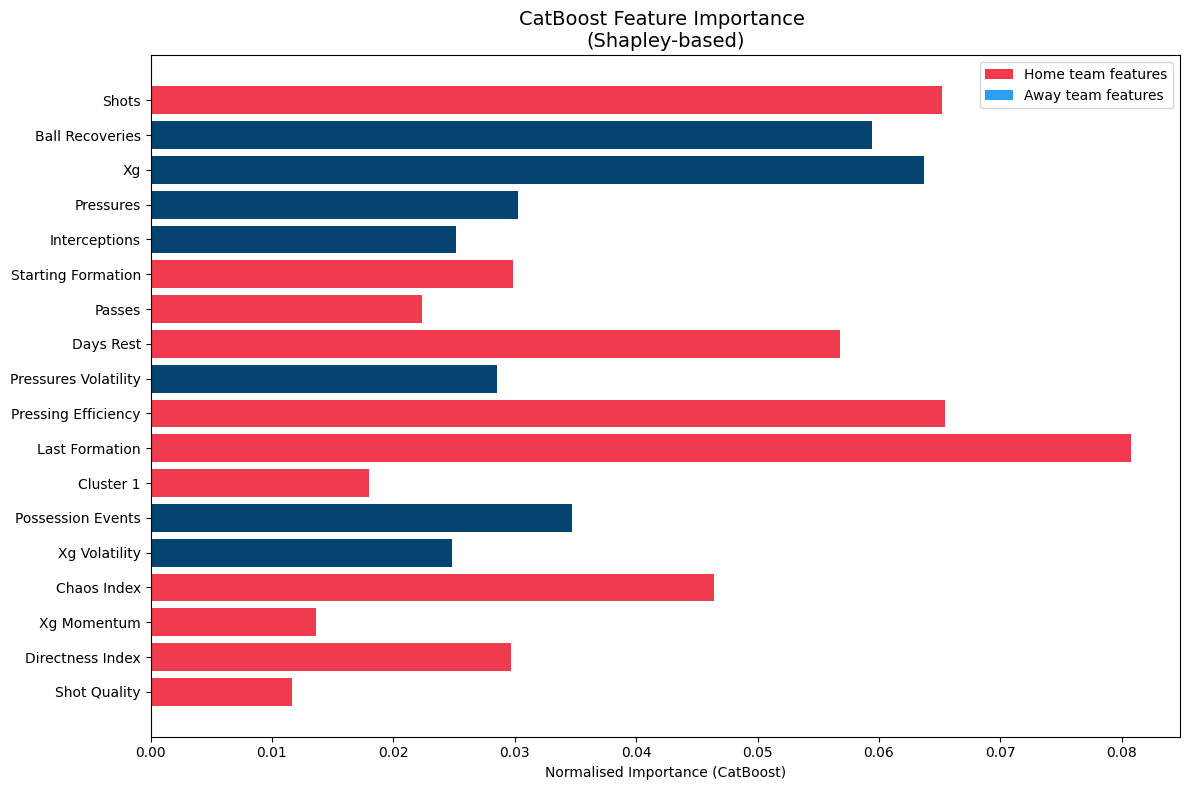


Top 15 Most Important Features:

                         Feature              Group  Normalized Importance
             home_last_formation Home team features               0.080759
home_pressing_efficiency_rolling Home team features               0.065417
              home_shots_rolling Home team features               0.065232
                 away_xg_rolling Away team features               0.063734
    away_ball_recoveries_rolling Away team features               0.059460
                  home_days_rest Home team features               0.056791
        home_chaos_index_rolling Home team features               0.046379
  away_possession_events_rolling Away team features               0.034691
          away_pressures_rolling Away team features               0.030280
         home_starting_formation Home team features               0.029850
   home_directness_index_rolling Home team features               0.029681
       away_pressures_volatility Away team features               

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from catboost import Pool

print("\nSHAPLEY-BASED FEATURE IMPORTANCE — CATBOOST\n")

cat_model = models_cv["CatBoost"]

feature_names = X_train.columns if hasattr(X_train, "columns") else [
    f"Feature_{i}" for i in range(X_train.shape[1])
]

X_shap = X_train.copy()
shap_pool = Pool(X_shap)

shap_values = cat_model.get_feature_importance(
    data=shap_pool,
    type="ShapValues"
)

shap_values = np.array(shap_values)

# Handle multiclass CatBoost SHAP output
# Shape may be: (samples, classes, features + 1)
if shap_values.ndim == 3:
    shap_values_only = shap_values[:, :, :-1]
    mean_abs_shap = np.abs(shap_values_only).mean(axis=(0, 1))

# Handle binary / regression CatBoost SHAP output
# Shape: (samples, features + 1)
elif shap_values.ndim == 2:
    shap_values_only = shap_values[:, :-1]
    mean_abs_shap = np.abs(shap_values_only).mean(axis=0)

else:
    raise ValueError(f"Unexpected SHAP shape: {shap_values.shape}")

feat_imp_df = pd.DataFrame({
    "Feature": list(feature_names),
    "Importance": mean_abs_shap
})

feat_imp_df["Normalized Importance"] = (
    feat_imp_df["Importance"] / feat_imp_df["Importance"].sum()
)

def feature_group(feature):
    f = feature.lower()
    if f.startswith("home_") or "home" in f:
        return "Home team features"
    elif f.startswith("away_") or "away" in f:
        return "Away team features"
    else:
        return "Other"

feat_imp_df["Group"] = feat_imp_df["Feature"].apply(feature_group)

def clean_name(feature):
    feature = feature.replace("home_", "").replace("away_", "")
    feature = feature.replace("_rolling", "")
    feature = feature.replace("_", " ")
    return feature.title()

feat_imp_df["Clean Feature"] = feat_imp_df["Feature"].apply(clean_name)

feat_imp_df = feat_imp_df.sort_values("Normalized Importance", ascending=True)
plot_df = feat_imp_df.tail(30)

colors = plot_df["Group"].map({
    "Home team features": "#ef3b4d",
    "Away team features": "#054471",
    "Other": "gray"
})

plt.figure(figsize=(12, 8))

plt.barh(
    plot_df["Clean Feature"],
    plot_df["Normalized Importance"],
    color=colors
)

plt.title(
    "CatBoost Feature Importance \n"
    "(Shapley-based)",
    fontsize=14
)

plt.xlabel("Normalised Importance (CatBoost)")
plt.ylabel("")

legend_elements = [
    Patch(facecolor="#ef3b4d", label="Home team features"),
    Patch(facecolor="#2c9df0", label="Away team features")
]

plt.legend(handles=legend_elements, loc="upper right")

plt.tight_layout()
plt.show()

print("\nTop 15 Most Important Features:\n")
print(
    feat_imp_df[["Feature", "Group", "Normalized Importance"]]
    .sort_values("Normalized Importance", ascending=False)
    .head(15)
    .to_string(index=False)
)

## Importing the models used for the engine

In [ ]:
import joblib


# 1. Save the Scikit-Learn objects using joblib
joblib.dump(scaler, 'sim2win_scaler.pkl')
joblib.dump(kmeans, 'sim2win_kmeans.pkl')

# 2. Save the Feature Columns list
# (Assuming X_train is your dataframe before scaling)
feature_cols = X_train.columns.tolist() if hasattr(X_train, 'columns') else X_train_scaled_columns
joblib.dump(feature_cols, 'sim2win_columns.pkl')

# 3. Save XGBoost using its native format (safer than pickle for XGBoost)
# Assuming 'xgb_search.best_estimator_' is your final model
xgb_model = models_cv['XGBoost'] # Or wherever your final model is stored
xgb_model.save_model('sim2win_xgb.json')

# Saving CatBoost using its native format
cat_model = models_cv['CatBoost']
cat_model.save_model('sim2win_catboost.cbm')

print("All models successfully saved to disk!")

All models successfully saved to disk!
